In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("/content/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [3]:
print(df.shape)
print(df['Class'].value_counts())

(25838, 31)
Class
0.0    25749
1.0       88
Name: count, dtype: int64


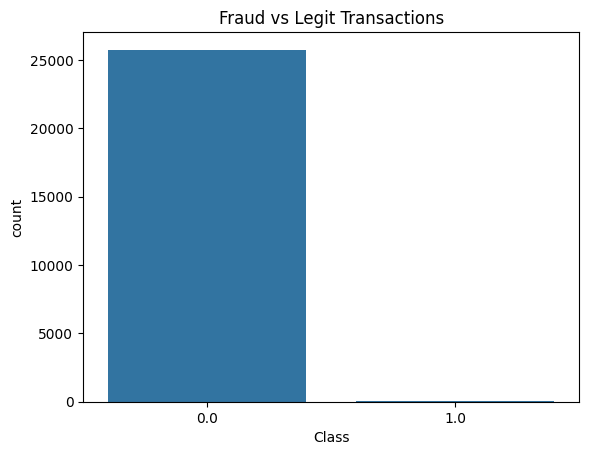

In [4]:
sns.countplot(x='Class',data=df)

plt.title("Fraud vs Legit Transactions")

plt.show()

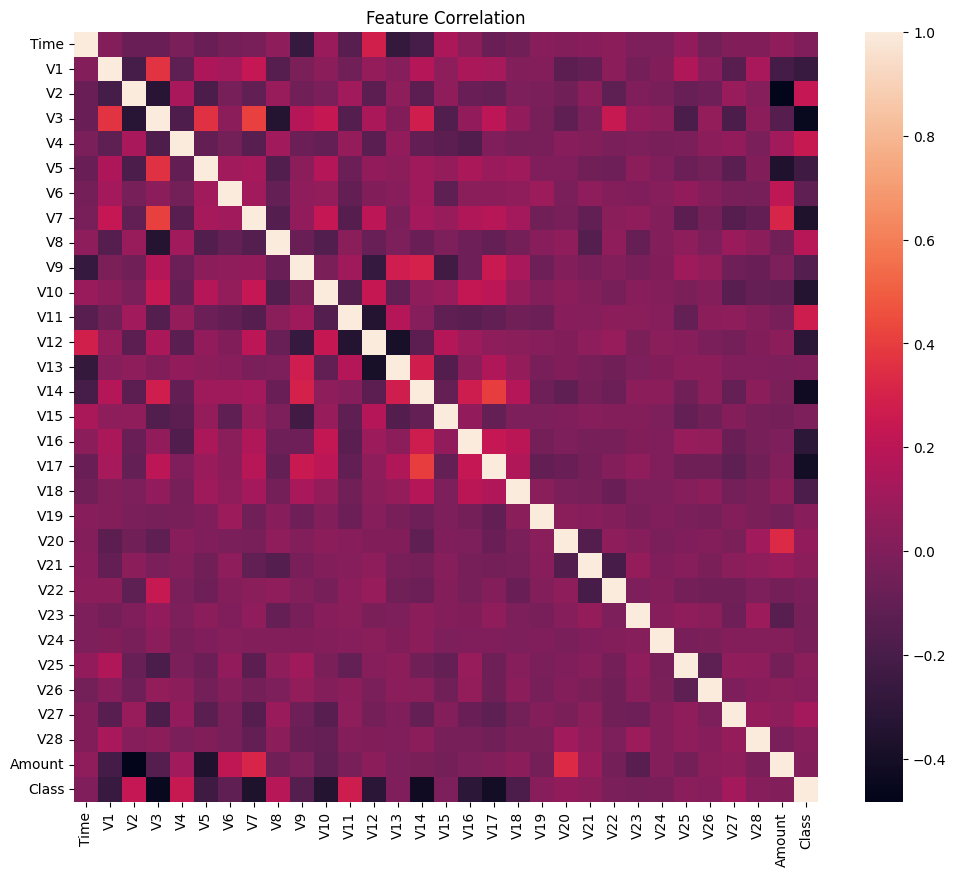

In [5]:
plt.figure(figsize=(12,10))

sns.heatmap(df.corr())

plt.title("Feature Correlation")

plt.show()

In [6]:
X = df.drop("Class",axis=1)
y = df["Class"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=200)
}

# Create a temporary combined dataframe to drop rows with NaNs consistently
# for X_train, y_train and X_test, y_test. The target column is named 'Class'.

# Clean X_train and y_train
train_combined = pd.concat([X_train, y_train], axis=1)
train_combined_cleaned = train_combined.dropna()
X_train_cleaned = train_combined_cleaned.drop(columns='Class')
y_train_cleaned = train_combined_cleaned['Class']

# Clean X_test and y_test
test_combined = pd.concat([X_test, y_test], axis=1)
test_combined_cleaned = test_combined.dropna()
X_test_cleaned = test_combined_cleaned.drop(columns='Class')
y_test_cleaned = test_combined_cleaned['Class']

for name, model in models.items():
    model.fit(X_train_cleaned, y_train_cleaned)
    pred = model.predict(X_test_cleaned)
    print(name)
    print(classification_report(y_test_cleaned, pred))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      5149
         1.0       0.65      0.61      0.63        18

    accuracy                           1.00      5167
   macro avg       0.82      0.80      0.81      5167
weighted avg       1.00      1.00      1.00      5167

Decision Tree
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      5149
         1.0       0.70      0.78      0.74        18

    accuracy                           1.00      5167
   macro avg       0.85      0.89      0.87      5167
weighted avg       1.00      1.00      1.00      5167

Random Forest
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      5149
         1.0       0.88      0.78      0.82        18

    accuracy                           1.00      5167
   macro avg       0.94      0.89      0.91      5167
weighted avg       1.00   

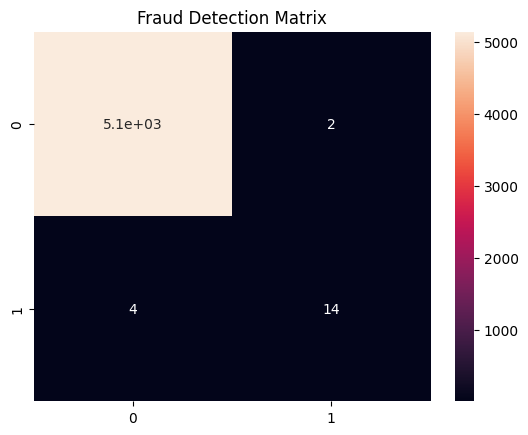

In [8]:
model = RandomForestClassifier()

model.fit(X_train_cleaned, y_train_cleaned)

pred = model.predict(X_test_cleaned)

cm = confusion_matrix(y_test_cleaned, pred)

sns.heatmap(cm,annot=True)

plt.title("Fraud Detection Matrix")

plt.show()

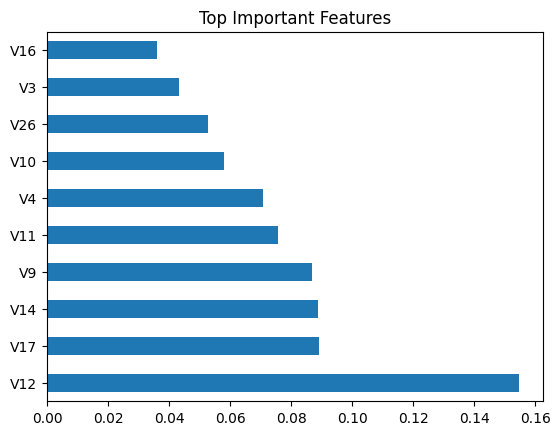

In [9]:
importances = model.feature_importances_

feat_imp = pd.Series(importances,index=X.columns)

feat_imp.nlargest(10).plot(kind='barh')

plt.title("Top Important Features")

plt.show()